# Figure 4 -- Direct fit to saturation-mutagenesis data

Reproduces the fitted TF weights from the model trained directly on the 40-AR-enhancer
saturation-mutagenesis dataset (Methods 2.7), and the overlap of its significant TFs with
the LogFC and LogDHT (STARR-seq tile-fit) models (Fig. 4B/C).

Expects `../output_files/` to contain `Ridge_coef_bootstrapped_MutModel_BestConfig_...647mots.npy`
(produced by `train_mutagen_pipeline.py`) and the LogFC/LogDHT bootstrapped coefficients
(produced by `train_model_pipeline.py`, same files used for Figure 2).

In [1]:
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

sys.path.insert(0, os.path.join('..', 'plotting'))
sys.path.insert(0, os.path.join('..', 'motif_model'))
from plot_utils import plot_x0s0_ws, return_sig_tfs
from data_preps import Motifs

OUTPUT_DIR = '../output_files'
INPUT_DIR = '../input_files'
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

with np.load(f'{INPUT_DIR}/motifs_dict_PWM_pseudo_bg_exp3_JaspHomoLV24_293tf_647mots_LNCaP_aligned.npz') as d:
    motif_pwms = {k: d[k] for k in d.files}
with np.load(f'{INPUT_DIR}/HOCO_uniprot_to_gene.npz') as d:
    conversion = {k: d[k] for k in d.files}
tfs = np.unique(Motifs(motif_pwms, conversion).mot_tfs)

c:\Users\Hoda Taeb\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Figure 4A -- Fitted TF weights, mutagenesis-fit model

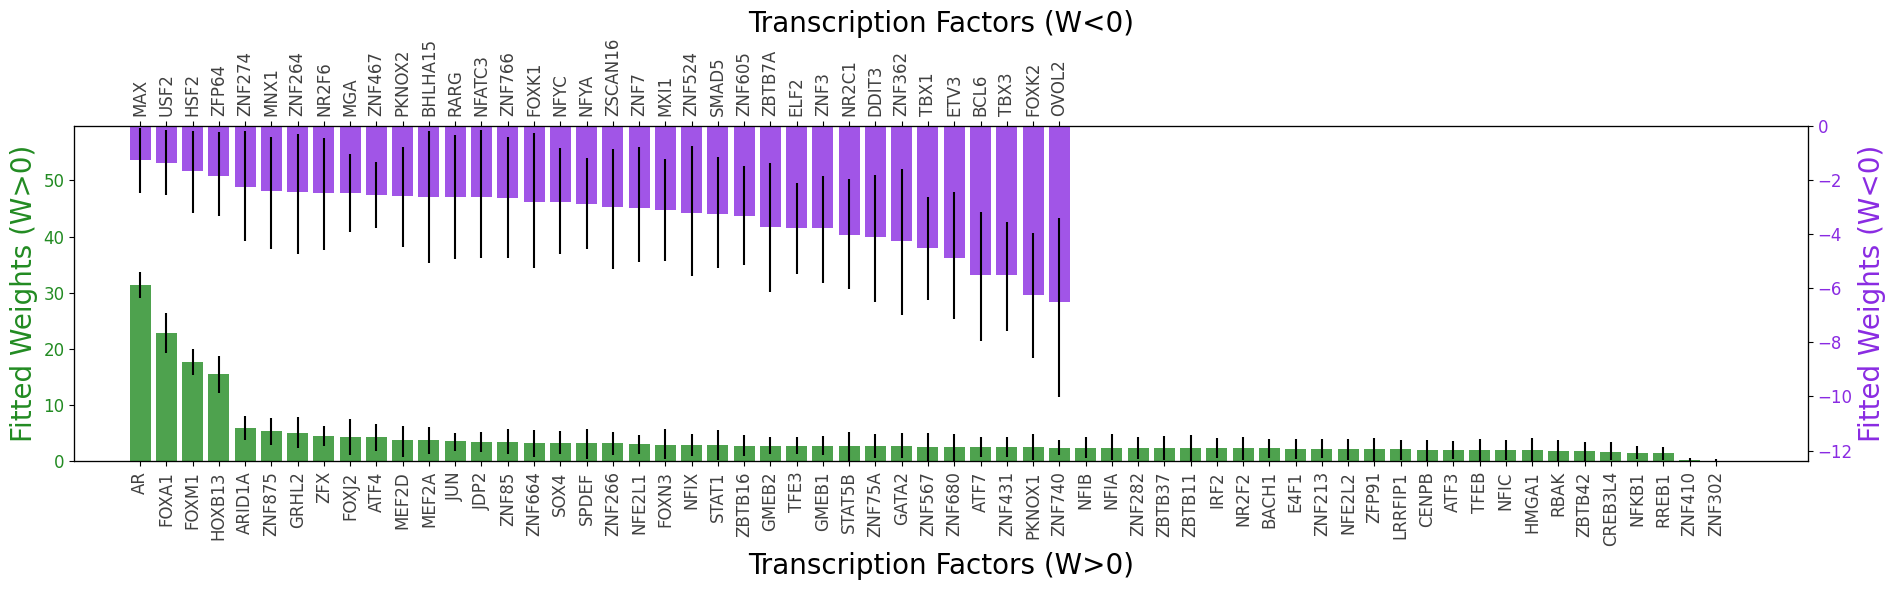

In [2]:
coef_bs_mut = np.load(glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_coef_bootstrapped_MutModel_BestConfig_*647mots.npy'))[0])

fig = plot_x0s0_ws(coef_bs_mut, tfs, CI=95, fig_size=6, fig_length_coef=2.5, ylim_coef=0.9,
                    neg_barcolor='blueviolet', pos_barcolor='ForestGreen', alpha=0.8)
fig.savefig(f'{FIGURES_DIR}/fig4a_mutagenesis_model_weights.pdf', dpi=200, bbox_inches='tight')
plt.show()

## Figure 4B/C -- Overlap with LogFC and LogDHT model significant TFs

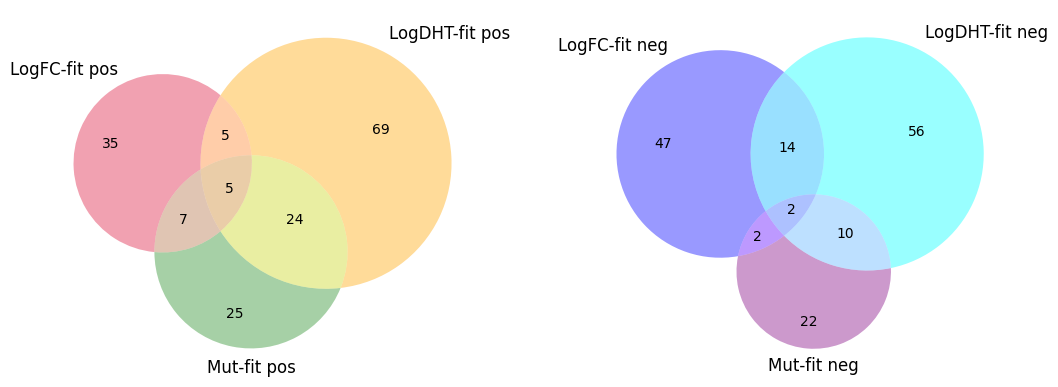

In [3]:
coef_bs_lfc = np.load(glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_coef_bootstrapped_lfc_bin700bp_avgpooling_S0_*647mots.npy'))[0])
coef_bs_dht = np.load(glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_coef_bootstrapped_dht_bin700bp_maxpooling_S0_*647mots.npy'))[0])

lfc_pos, lfc_neg = return_sig_tfs(coef_bs_lfc, tfs, CI=95)
dht_pos, dht_neg = return_sig_tfs(coef_bs_dht, tfs, CI=95)
mut_pos, mut_neg = return_sig_tfs(coef_bs_mut, tfs, CI=95)

lfc_pos, lfc_neg = set(lfc_pos), set(lfc_neg)
dht_pos, dht_neg = set(dht_pos), set(dht_neg)
mut_pos, mut_neg = set(mut_pos), set(mut_neg)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
venn3([lfc_pos, dht_pos, mut_pos], ('LogFC-fit pos', 'LogDHT-fit pos', 'Mut-fit pos'),
      set_colors=('crimson', 'orange', 'ForestGreen'), ax=axes[0])
venn3([lfc_neg, dht_neg, mut_neg], ('LogFC-fit neg', 'LogDHT-fit neg', 'Mut-fit neg'),
      set_colors=('blue', 'cyan', 'purple'), ax=axes[1])
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig4bc_mutagenesis_overlap_venn.pdf', dpi=200, bbox_inches='tight')
plt.show()

In [4]:
A = lfc_pos & dht_pos & mut_pos
print('Group A:', A)
print('Group B:', lfc_pos & mut_pos - A)
print('Group C:', dht_pos & mut_pos - A)

Group A: {'FOXA1', 'SPDEF', 'ZNF740', 'FOXM1', 'CENPB'}
Group B: {'ATF7', 'ZBTB16', 'NFIC', 'HOXB13', 'ARID1A', 'NFIA', 'AR'}
Group C: {'MEF2A', 'BACH1', 'ATF3', 'FOXN3', 'ZNF213', 'SOX4', 'NFE2L1', 'NFE2L2', 'ZNF431', 'ZFP91', 'ZBTB11', 'ATF4', 'GMEB2', 'RBAK', 'ZNF664', 'E4F1', 'STAT1', 'IRF2', 'TFEB', 'GRHL2', 'LRRFIP1', 'CREB3L4', 'ZNF282', 'ZFX'}


In [5]:
import pandas as pd

def sign_column(pos_set, neg_set):
    col = pd.Series('ns', index=tfs)
    col[list(pos_set)] = '+'
    col[list(neg_set)] = '-'
    return col

table_overlap = pd.DataFrame({
    'TF': tfs,
    'LogFC': sign_column(lfc_pos, lfc_neg).values,
    'LogDHT': sign_column(dht_pos, dht_neg).values,
    'LogFC_mut': sign_column(mut_pos, mut_neg).values,
})

# Keep only TFs significant in at least one model
table_overlap = table_overlap[(table_overlap[['LogFC', 'LogDHT', 'LogFC_mut']] != 'ns').any(axis=1)]
table_overlap = table_overlap.sort_values(['LogFC_mut', 'LogFC', 'LogDHT', 'TF'])

table_overlap.to_csv(f'{FIGURES_DIR}/fig4c_mutagenesis_overlap_table.csv', index=False)
table_overlap

,TF,LogFC,LogDHT,LogFC_mut
15,CENPB,+,+,+
40,FOXA1,+,+,+
44,FOXM1,+,+,+
147,SPDEF,+,+,+
277,ZNF740,+,+,+
...,...,...,...,...
246,ZNF441,ns,-,ns
256,ZNF562,ns,-,ns
260,ZNF586,ns,-,ns
276,ZNF74,ns,-,ns
